In [1]:
%%capture --no-stderr
%pip install --upgrade --quiet langchain-community langgraph

You should consider upgrading via the 'c:\Users\NageshN\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import requests
import sqlite3

# Step 1: Download the SQL file
url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
sql_script = requests.get(url).text

# Step 2: Create the database
conn = sqlite3.connect("Chinook.db")
cursor = conn.cursor()
cursor.executescript(sql_script)
conn.commit()
conn.close()

In [3]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("Chinook.db")

# Step 1: Get all table names
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(tables_query, conn)['name'].tolist()

# Step 2: Loop through tables and display first 3 rows
for table in tables:
    print(f"\n📌 Table: {table}")
    try:
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 3;", conn)
        display(df)  # Only works in Jupyter
    except Exception as e:
        print(f"❌ Error reading table {table}: {e}")

conn.close()



📌 Table: Album


,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2



📌 Table: Artist


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith



📌 Table: Customer


...

,PlaylistId,Name
0,1,Music
1,2,Movies
2,3,TV Shows



📌 Table: PlaylistTrack


,PlaylistId,TrackId
0,1,3402
1,1,3389
2,1,3390



📌 Table: Track


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99


In [4]:
#import sys
#sys.path.append("scripts")

import sys
sys.path.append("../scripts")  # relative path from notebook to scripts folder

#db_path = r"C:\Users\NageshN\Documents\Documents 2\Documents\Unilever Project - Procurement Analytics\Proc GPT KT\FC GPT\Demo\data\Chinook.db"
#output_path = r"C:\Users\NageshN\Documents\Documents 2\Documents\Unilever Project - Procurement Analytics\Proc GPT KT\FC GPT\Demo\data\Chinook.dbml"

from sqlite_to_dbml import sqlite_to_dbml

db_path = "../data/Chinook.db"
output_path = "../data/Chinook.dbml"


# Execute
sqlite_to_dbml(db_path, output_path)

DBML schema written to ../data/Chinook.dbml


In [5]:
# Add scripts folder to Python path
import sys
sys.path.append("../scripts")

# Import the module
import export_chinook_excel

# Reload the module to pick up any changes
import importlib
importlib.reload(export_chinook_excel)

# Execute the function to export all Chinook tables to Excel
export_chinook_excel.export_all_tables()



Export complete: ../data/Chinook_all_tables.xlsx


In [6]:
from typing_extensions import TypedDict


class State(TypedDict):
    question: str
    query: str
    result: str
    answer: str

In [7]:
pip install -qU "langchain[google-genai]"

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\NageshN\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Requesting the User to Input the API Key

In [8]:
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4o-mini", model_provider="openai")

Prompt Template Creation and System Messages


In [9]:
from langchain_core.prompts import ChatPromptTemplate

"""system_message = 
Given an input question, create a syntactically correct {dialect} query to
run to help find the answer. Unless the user specifies in his question a
specific number of examples they wish to obtain, always limit your query to
at most {top_k} results. You can order the results by a relevant column to
return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the
few relevant columns given the question.

Only use the exact table and column names as provided in {table_info}.
Do not make up table or column names.
Also,
pay attention to which column is in which table.

Only use the following tables:
{table_info}
"""


system_message = """
You are an expert SQL generator.

Given an input question, generate a syntactically correct {dialect} SQL query to answer the question.

ONLY use the table and column names exactly as provided in the schema below.

Do not rename or modify any table or column names. Do not guess. Do not use plural or singular variations. Do not add aliases unless explicitly required by the question.
If a table is named `Employee`, DO NOT use `Employees`.
If a table is named `OrderDetails`, DO NOT use `OrderDetail`.
Always use the table and column names EXACTLY as shown below. No corrections. No guesses.

Never query for all columns (no SELECT *). Select only the relevant columns based on the question.

Unless the question asks for more, limit your results to at most {top_k} rows. You can sort the results using a relevant column if appropriate.




### Database schema:
{table_info}

### Example format:
```sql
SELECT column1, column2 FROM table_name WHERE ... LIMIT {top_k};

"""

user_prompt = "Question: {input}"

query_prompt_template = ChatPromptTemplate(
    [("system", system_message), ("user", user_prompt)]
)

for message in query_prompt_template.messages:
    message.pretty_print()

================================ System Message ================================


You are an expert SQL generator.

Given an input question, generate a syntactically correct {dialect} SQL query to answer the question.

ONLY use the table and column names exactly as provided in the schema below.

Do not rename or modify any table or column names. Do not guess. Do not use plural or singular variations. Do not add aliases unless explicitly required by the question.
If a table is named `Employee`, DO NOT use `Employees`.
If a table is named `OrderDetails`, DO NOT use `OrderDetail`.
Always use the table and column names EXACTLY as shown below. No corrections. No guesses.

Never query for all columns (no SELECT *). Select only the relevant columns based on the question.

Unless the question asks for more, limit your results to at most {top_k} rows. You can sort the results using a relevant column if appropriate.




### Database schema:
{table_info}

### Example format:
```sql
SELECT column

In [10]:
## Notes for self learning

'''system_message = "A very long message giving specific instructions to the model, can include database schema details"
user_prompt = "Question: {Input}"

query_prompt_template = ChatPromptTemplate ([
    ("system", system_message),('user', user_prompt)
])'''

'system_message = "A very long message giving specific instructions to the model, can include database schema details"\nuser_prompt = "Question: {Input}"\n\nquery_prompt_template = ChatPromptTemplate ([\n    ("system", system_message),(\'user\', user_prompt)\n])'

In [11]:
query_prompt_template.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['dialect', 'table_info', 'top_k'], input_types={}, partial_variables={}, template='\nYou are an expert SQL generator.\n\nGiven an input question, generate a syntactically correct {dialect} SQL query to answer the question.\n\nONLY use the table and column names exactly as provided in the schema below.\n\nDo not rename or modify any table or column names. Do not guess. Do not use plural or singular variations. Do not add aliases unless explicitly required by the question.\nIf a table is named `Employee`, DO NOT use `Employees`.\nIf a table is named `OrderDetails`, DO NOT use `OrderDetail`.\nAlways use the table and column names EXACTLY as shown below. No corrections. No guesses.\n\nNever query for all columns (no SELECT *). Select only the relevant columns based on the question.\n\nUnless the question asks for more, limit your results to at most {top_k} rows. You can sort the results using a relevant column if appropria

In [12]:
for message in query_prompt_template.messages:
    print(message.input_variables)

['dialect', 'table_info', 'top_k']
['input']


Query Generation with a user input

In [13]:
from typing_extensions import Annotated


class QueryOutput(TypedDict):
    """Generated SQL query."""

    query: Annotated[str, ..., "Syntactically valid SQL query."]

def write_query(state: State) -> State:
    
    """Generate SQL query to fetch information."""

    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)

    return {
        **state,
        "query": result["query"]
    }


In [14]:
blank_state = {
    "question": "",
    "query": "",
    "result": "",
    "answer": ""
}
blank_state["question"] = "How many Employees are there?"

from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")
blank_state = write_query(blank_state)
print(blank_state)


{'question': 'How many Employees are there?', 'query': 'SELECT COUNT(*) as EmployeeCount FROM Employee;', 'result': '', 'answer': ''}


Query Execution Function using a Langchain Tool

In [15]:
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool

def execute_query(state: State) -> State:
    """Execute SQL query and return updated state with result."""
    execute_query_tool = QuerySQLDatabaseTool(db=db)
    
    result = execute_query_tool.invoke(state["query"])

    return {
        **state,           # Keep all existing keys (question, query, answer)
        "result": result   # Add/update the result key
    }


In [16]:
blank_state = execute_query(blank_state)
print(blank_state)

{'question': 'How many Employees are there?', 'query': 'SELECT COUNT(*) as EmployeeCount FROM Employee;', 'result': '[(8,)]', 'answer': ''}


Generating an Answer

In [17]:
def generate_answer(state: State) -> State:
    """Answer question using retrieved information as context."""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f"Question: {state['question']}\n"
        f"SQL Query: {state['query']}\n"
        f"SQL Result: {state['result']}"
    )
    response = llm.invoke(prompt)

    return {
        **state,                      # preserve all previous fields
        "answer": response.content   # add new field
    }


In [18]:
blank_state = generate_answer(blank_state)
print(blank_state)

{'question': 'How many Employees are there?', 'query': 'SELECT COUNT(*) as EmployeeCount FROM Employee;', 'result': '[(8,)]', 'answer': 'There are 8 Employees.'}


In [19]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence(
    [write_query, execute_query, generate_answer]
)
graph_builder.add_edge(START, "write_query")
graph = graph_builder.compile()

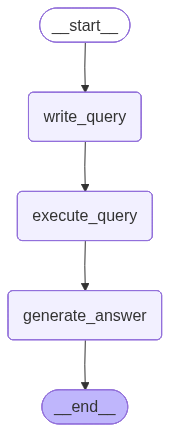

In [20]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
for step in graph.stream(
    {"question": "How many employees are there?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'question': 'How many employees are there?', 'query': 'SELECT COUNT(*) AS EmployeeCount FROM Employee;'}}
{'execute_query': {'question': 'How many employees are there?', 'query': 'SELECT COUNT(*) AS EmployeeCount FROM Employee;', 'result': '[(8,)]'}}
{'generate_answer': {'question': 'How many employees are there?', 'query': 'SELECT COUNT(*) AS EmployeeCount FROM Employee;', 'result': '[(8,)]', 'answer': 'There are 8 employees.'}}


In [22]:
result = graph.invoke({"question": "How many employees are there?"})

print(result)

{'question': 'How many employees are there?', 'query': 'SELECT COUNT(*) AS employee_count FROM Employee;', 'result': '[(8,)]', 'answer': 'There are 8 employees.'}


In [23]:
result['answer']

'There are 8 employees.'

In [24]:
result_2 = graph.invoke({"question": "How many customers are there?"})

print(result_2)

{'question': 'How many customers are there?', 'query': 'SELECT COUNT(CustomerId) FROM Customer;', 'result': '[(59,)]', 'answer': 'There are 59 customers.'}


Executing the same with an Agentic Architecture

In [25]:
## Step 1 - Importing the SQL toolkit which contains different SQL tools


from langchain_community.agent_toolkits import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

tools = toolkit.get_tools()

tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001A7DA694400>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001A7DA694400>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001A7DA694400>),
 QuerySQLCheckerTool(description='Use this tool to 

Creating a system message for the agent

In [26]:
system_message_agent = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

You MUST double check your query before executing it. If you get an error while
executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the
database.

To start you should ALWAYS look at the tables in the database to see what you
can query. Do NOT skip this step.

Then you should query the schema of the most relevant tables.
""".format(
    dialect="SQLite",
    top_k=5,
)

Initializing the Agent

In [27]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(llm, tools, prompt=system_message_agent)

Executing the Agent as well as tracing the intermediate steps for understanding

In [28]:
question = "Which country's customers spent the most?"

for step in agent_executor.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which country's customers spent the most?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_IwMHBzK7H1JE9PATHud00wCt)
 Call ID: call_IwMHBzK7H1JE9PATHud00wCt
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_3yAllFIPpPIiUuNZdXQh1HH3)
 Call ID: call_3yAllFIPpPIiUuNZdXQh1HH3
  Args:
    table_names: Customer
  sql_db_schema (call_Ub17wCZdTBtXZ34zTI5Vt8Ld)
 Call ID: call_Ub17wCZdTBtXZ34zTI5Vt8Ld
  Args:
    table_names: Invoice
  sql_db_schema (call_BlggTFnGzSdY4mwyiWKDMl5Q)
 Call ID: call_BlggTFnGzSdY4mwyiWKDMl5Q
  Args:
    table_names: InvoiceLine
========

Agent Execution without the displaying intermediate steps and only the final output

In [29]:
# User's natural language question
question = "Which country's customers spent the most?"

# Invoke agent and get final result (no intermediate steps)
result = agent_executor.invoke({
    "messages": [{"role": "user", "content": question}]
})

# Extract and print only the final message
print("Final Answer:", result["messages"][-1].content)


Final Answer: The countries where customers spent the most are:

1. **USA**: $523.06
2. **Canada**: $303.96
3. **France**: $195.10
4. **Brazil**: $190.10
5. **Germany**: $156.48


Running a testing script to check the accuracy of the agent

In [31]:
sample_questions = [
        "How many customers are there?",
        "How many employees are there?",
        "How many albums are there?",
        "How many tracks are in the database?",
        "What is the total number of invoices?",
        "What is the total sales (sum) of all invoices?",
        "What is the total number of genres?",
        "Which country has the most customers?",
        "Which city has the highest total invoice amount?",
        "Who is the best customer (spent the most)?",
        "How many invoices were created in 2009?",
        "How many invoices were created in 2011?",
        "List all employees who are sales agents.",
        "Which artist sold the most tracks?",
        "Which artist earned the most from track sales?",
        "What is the average invoice total?",
        "Which genre is most popular?",
        "How many playlists are there?",
        "Which playlist has the most tracks?",
        "Which media type is used most often?",
        "What is the average length of a track?",
        "List tracks longer than the average track length.",
        "What are the top 5 customers by invoice total?",
        "List invoice count per country.",
        "List customer count per support representative (employee).",
        "What are the albums by artists containing 'black' in their name?",
        "What are the distinct billing countries in invoice table?",
        "Which album has the most tracks?",
        "How many tracks are in each album?",
        "What are the most expensive tracks (by unit price)?",
        "What is the cheapest track?",
        "What is the total number of invoice line items?",
        "What is the total sales grouped by country?",
        "Which sales agent made the most in 2009?",
        "Which sales agent made the most in 2010?",
        "Which sales agent made the most overall?",
        "What are the customers from Brazil?",
        "What are the invoices for customers in Brazil?",
        "What is the most popular genre in each country?",
        "Which customers listened to Rock music?",
        "Which artists wrote Rock music (artist + track count)?",
        "What is the total sales for each artist?",
        "Which artist has the highest number of tracks?",
        "What is the album title with AlbumId 67?",
        "List name and length (in seconds) of tracks between 50 and 70 seconds.",
        "What are the albums by artists whose names have 'the' in them?",
        "Which customers have not made any invoices?",
        "Which tracks are never sold (never appear in invoice_line)?",
        "Which invoices have more than 3 line items?",
        "Which invoice had the highest number of line items?",
        "Which genre has the highest average unit price of tracks?"
    ]

In [32]:
# main.py

from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langgraph.prebuilt import create_react_agent
from agent_test_runner import test_agent

# Setup (assuming db and llm are already initialized)
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()

# Agent prompt
#system_message_agent = """
#You are an agent designed to interact with a SQL database.
#... (same as before)
#""".format(dialect="SQLite", top_k=5)

# Create agent executor
agent_executor = create_react_agent(llm, tools, prompt=system_message_agent)

# List of questions
questions = [
    "How many employees are there?",
    "List the top 3 customers by total invoice amount.",
    "What is the average duration of a track?",
    "Which country's customers spent the most?",
    "Which artist has the most albums?"
]

# Run the test
df_results = test_agent(agent_executor, sample_questions)



Testing: How many customers are there?

Testing: How many employees are there?

Testing: How many albums are there?

Testing: How many tracks are in the database?

Testing: What is the total number of invoices?

Testing: What is the total sales (sum) of all invoices?

Testing: What is the total number of genres?

Testing: Which country has the most customers?

Testing: Which city has the highest total invoice amount?

Testing: Who is the best customer (spent the most)?

Testing: How many invoices were created in 2009?

Testing: How many invoices were created in 2011?

Testing: List all employees who are sales agents.

Testing: Which artist sold the most tracks?

Testing: Which artist earned the most from track sales?

Testing: What is the average invoice total?

Testing: Which genre is most popular?

Testing: How many playlists are there?

Testing: Which playlist has the most tracks?

Testing: Which media type is used most often?

Testing: What is the average length of a track?

Testi

In [33]:
# User's natural language question
question = "Which country's customers spent the most?"

# Invoke agent and get final result (no intermediate steps)
result = agent_executor.invoke({
    "messages": [{"role": "user", "content": question}]
})

# Extract and print only the final message
print("Final Answer:", result["messages"][-1].content)

Final Answer: The countries whose customers spent the most are:

1. **USA**: $523.06
2. **Canada**: $303.96
3. **France**: $195.10
4. **Brazil**: $190.10
5. **Germany**: $156.48
